
# ประสิทธิภาพ IO Backend

ใช้ประโยชน์จากแบ็กเอนด์ IO ที่แตกต่างกันสำหรับการจัดเก็บผลลัพธ์ inference

ตัวอย่างนี้สำรวจแบ็กเอนด์ IO ภายใน Earth2Studio และวิธีการใช้ในการเขียน
ข้อมูลในรูปแบบ/ตำแหน่งต่างๆ IO เป็นส่วนหลักของไปป์ไลน์ inference
และขึ้นอยู่กับเป้าหมายที่ต้องการ อาจส่งผลกระทบอย่างมากต่อประสิทธิภาพการทำงาน ตัวอย่างนี้
จะช่วยนำทางผู้ใช้ผ่านการใช้งาน IO Backend API ที่แตกต่างกันได้อย่างง่ายดาย
workflow.

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- การเริ่มต้น การสร้างอาร์เรย์ และการเขียนด้วย Zarr IO Backend
- การเริ่มต้น การสร้างอาร์เรย์ และการเขียนด้วย NetCDF IO Backend
- การเริ่มต้นและการเขียนด้วย Asynchronous Non-blocking Zarr IO Backend
- อภิปรายถึงผลการปฏิบัติงานและกลยุทธ์ที่สามารถนำมาใช้ได้


In [1]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "matplotlib",
# ]
# ///

## การเตรียมองค์ประกอบ
เพื่อสาธิต IO ที่แตกต่างกัน ตัวอย่างนี้จะใช้ ensemble workflow แบบง่ายๆ ที่เรา
จะสร้างตัวเราเองขึ้นมาเอง เราสามารถใช้ workflow ในตัวใน Earth2Studio
อย่างไรก็ตาม สิ่งนี้จะช่วยให้เราเข้าใจ API ได้ดีขึ้น



เราจำเป็นต้องมีคอมโพเนนต์ต่อไปนี้:

- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- Prognostic Model: ใช้ DLWP รุ่น :py:class:`earth2studio.models.px.DLWP` ในตัว
- วิธีการก่อกวน: ใช้วิธีเกาส์เซียนมาตรฐาน :py:class:`earth2studio.perturbation.Gaussian`
- IO Backends: ใช้ IO Backend บางตัว รวมถึง :py:class:`earth2studio.io.AsyncZarrBackend`, :py:class:`earth2studio.io.NetCDF4Backend` และ :py:class:`earth2studio.io.ZarrBackend`



In [2]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

import torch

from earth2studio.data import GFS, DataSource, fetch_data
from earth2studio.io import AsyncZarrBackend, IOBackend, NetCDF4Backend, ZarrBackend
from earth2studio.models.px import DLWP, PrognosticModel
from earth2studio.perturbation import Gaussian, Perturbation

# รับอุปกรณ์
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# โหลดแหล่งข้อมูล cBottle
package = DLWP.load_default_package()
model = DLWP.load_model(package)
model = model.to(device)

# สร้างแหล่งข้อมูล ERA5
ds = GFS()

# สร้างวิธีการก่อกวน
pt = Gaussian()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature


## การสร้างเวิร์กโฟลว์ Ensemble อย่างง่าย
เริ่มต้นด้วยการสร้าง ensemble inference workflow แบบง่ายๆ โดยพื้นฐานแล้วนี่คือก
เวอร์ชันที่เรียบง่ายกว่าของ ensemble workflow :py:meth:`earth2studio.run.ensemble` ในตัว
ในกรณีนี้ สำหรับ ensemble inference workflow ที่จะทำนาย 5 วัน
forecast สำหรับคริสต์มาสปี 2022 เป็นไปตามหลักปฏิบัติ Earth2Studio มาตรฐาน ฟังก์ชัน
ยอมรับการพยากรณ์เริ่มต้น แหล่งข้อมูล IO Backend และวิธีการก่อกวน



In [3]:
import os
import time
from datetime import datetime, timedelta

import numpy as np
from tqdm import tqdm

from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array

times = [datetime(2022, 12, 20)]
nsteps = 20  # สมมติว่าเวลาเป็นขั้นตอน 6 ชั่วโมง


def christmas_five_day_ensemble(
    times: list[datetime],
    nsteps: int,
    prognostic: PrognosticModel,
    data: DataSource,
    io: IOBackend,
    perturbation: Perturbation,
    nensemble: int = 8,
    device: str = "cuda",
) -> None:
    """Ensemble inference example"""
    # ==========================================
    # ดึงข้อมูลการเริ่มต้น
    prognostic_ic = prognostic.input_coords()
    times = to_time_array(times)

    x, coords0 = fetch_data(
        source=data,
        time=times,
        variable=prognostic_ic["variable"],
        lead_time=prognostic_ic["lead_time"],
        device=device,
    )
    # ==========================================
    # ==========================================
    # ตั้งค่า IO Backend โดยการจัดสรรอาร์เรย์ล่วงหน้า (ไม่จำเป็นสำหรับ AsyncZarrBackend)
    total_coords = prognostic.output_coords(prognostic.input_coords()).copy()
    if "batch" in total_coords:
        del total_coords["batch"]
    total_coords["time"] = times
    total_coords["lead_time"] = np.asarray(
        [
            prognostic.output_coords(prognostic.input_coords())["lead_time"] * i
            for i in range(nsteps + 1)
        ]
    ).flatten()
    total_coords.move_to_end("lead_time", last=False)
    total_coords.move_to_end("time", last=False)
    total_coords = {"ensemble": np.arange(nensemble)} | total_coords

    variables_to_save = total_coords.pop("variable")
    io.add_array(total_coords, variables_to_save)
    # ==========================================
    # ==========================================
    # รัน inference
    coords = {"ensemble": np.arange(nensemble)} | coords0.copy()
    x = x.unsqueeze(0).repeat(nensemble, *([1] * x.ndim))

    # แผนที่ lat และ lon หากจำเป็น
    x, coords = map_coords(x, coords, prognostic_ic)

    # รบกวน ensemble
    x, coords = perturbation(x, coords)

    # สร้างตัววนซ้ำเชิงพยากรณ์
    model = prognostic.create_iterator(x, coords)

    with tqdm(
        total=nsteps + 1,
        desc="Running batch inference",
        position=1,
        leave=False,
    ) as pbar:
        for step, (x, coords) in enumerate(model):
            # ดัมพ์ผลลัพธ์ไปที่ IO โดย split_coords จะแยกตัวแปรออกเป็นอาร์เรย์ที่ต่างกัน
            x, coords = map_coords(x, coords, {"variable": np.array(["t2m", "tcwv"])})
            io.write(*split_coords(x, coords))
            pbar.update(1)
            if step == nsteps:
                break
    # ==========================================


def get_folder_size(folder_path: str) -> int:
    """Get folder size in megabytes"""
    if os.path.isfile(folder_path):
        return os.path.getsize(folder_path) / (1024 * 1024)

    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size / (1024 * 1024)

## ที่เก็บข้อมูลในเครื่อง Zarr IO
เป็นบรรทัดฐาน ให้รัน Zarr IO Backend บันทึกลงในโลคัลดิสก์
โดยทั่วไปแล้วพื้นที่เก็บข้อมูล IO ในเครื่องจะเป็นที่ต้องการเนื่องจากเราสามารถเข้าถึงข้อมูลได้หลังจากนั้น
ไปป์ไลน์ inference เสร็จสิ้นโดยใช้ไลบรารีมาตรฐาน
การแบ่งก้อนมีบทบาทสำคัญในประสิทธิภาพ ทั้งในด้านการบีบอัดและ
เมื่อเข้าถึงข้อมูลด้วย
ที่นี่เราจะแบ่งข้อมูลเอาต์พุตตามเวลาและ lead_time



In [4]:
io = ZarrBackend(
    "outputs/17_io_sync.zarr",
    chunks={"time": 1, "lead_time": 1},
    backend_kwargs={"overwrite": True},
)

start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
zarr_local_clock = time.time() - start_time

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:57:58.121 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 410101849-875378
2026-04-26 20:57:58.124 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 295463736-857297
2026-04-26 20:57:58.125 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 422682974-1171397
2026-04-26 20:57:58.127 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 251866913-804464
2026-04-26 20:57:58.128 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 209450878-718645
2026-04-26 20:57:58.140 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:22<00:00,  3.23s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xe21f62c7b8c0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xe21f6195c950>, 116633.103792166)])']
connector: <aiohttp.connector.TCPConnector object at 0xe21f62c7af90>
Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:58:23.087 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 331696727-829753
2026-04-26 20:58:23.089 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 210327553-720496
2026-04-26 20:58:23.092 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 400334303-985030
2026-04-26 20:58:23.094 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505
2026-04-26 20:58:23.095 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 296814817-852960
2026-04-26 20:58:23.097 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 7/7 [00:10<00:00,  1.56s/it]


In [5]:
print(f"\nLocal zarr store inference time: {zarr_local_clock}s")
print(
    f"Uncompressed zarr store size: {get_folder_size('outputs/17_io_sync.zarr'):.2f} MB"
)


Local zarr store inference time: 45.42785978317261s
Uncompressed zarr store size: 1330.78 MB


## ที่เก็บข้อมูลในเครื่องที่ถูกบีบอัด Zarr IO
ตามค่าเริ่มต้น แบ็กเอนด์ Zarr IO จะไม่ถูกบีบอัด
ในหลายกรณี สิ่งนี้เป็นเรื่องปกติเมื่อมีปริมาณข้อมูลต่ำ
อย่างไรก็ตามในกรณีที่เรากำลังเขียนข้อมูลหรือข้อมูลจำนวนมาก
จำเป็นต้องส่งผ่านเครือข่ายไปยังร้านค้าระยะไกล การบีบอัดข้อมูลถือเป็นสิ่งสำคัญ
ด้วยแบ็กเอนด์ Zarr มาตรฐาน จะทำให้การทำงานช้าลงอย่างเห็นได้ชัด แต่โปรดทราบ
ที่จัดเก็บเอาต์พุตจะเล็กลง 3 เท่า!



In [6]:
import zarr

io = ZarrBackend(
    "outputs/17_io_sync_compressed.zarr",
    chunks={"time": 1, "lead_time": 1},
    backend_kwargs={"overwrite": True},
    zarr_codecs=zarr.codecs.BloscCodec(
        cname="zstd", clevel=3, shuffle=zarr.codecs.BloscShuffle.shuffle
    ),  # Zarr เป็นค่าเริ่มต้น
)

start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
zarr_local_clock = time.time() - start_time

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xe21f618f3c50>
Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 118.50it/s]


2026-04-26 20:58:42.436 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 399402626-989950
2026-04-26 20:58:42.444 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 410101849-875378
2026-04-26 20:58:42.452 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 209450878-718645
2026-04-26 20:58:42.461 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 295463736-857297
2026-04-26 20:58:42.469 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 422682974-1171397
2026-04-26 20:58:42.478 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:58:42.527 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 296814817-852960
2026-04-26 20:58:42.535 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 331696727-829753
2026-04-26 20:58:42.544 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 400334303-985030
2026-04-26 20:58:42.552 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 423575610-1170377
2026-04-26 20:58:42.561 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505
2026-04-26 20:58:42.569 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 118.49it/s]


2026-04-26 20:58:42.578 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 410972364-870639


In [7]:
print(f"\nLocal compressed zarr store inference time: {zarr_local_clock}s")
print(
    f"Compressed zarr store size: {get_folder_size('outputs/17_io_sync_compressed.zarr'):.2f} MB"
)


Local compressed zarr store inference time: 12.655693292617798s
Compressed zarr store size: 394.38 MB


## ที่เก็บข้อมูลในเครื่อง NetCDF IO
NetCDF มอบประสบการณ์ผู้ใช้ที่คล้ายคลึงกัน แต่บันทึกเอาต์พุตไว้ใน netCDF เดียว
ไฟล์.
สำหรับที่จัดเก็บในตัวเครื่อง โดยปกติแล้ว NetCDF จะเลือกใช้เนื่องจากจะเก็บเอาต์พุตทั้งหมดไว้
ไฟล์เดียว



In [8]:
io = NetCDF4Backend("outputs/17_io_sync.nc", backend_kwargs={"mode": "w"})
start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
nc_local_clock = time.time() - start_time

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 113.61it/s]


2026-04-26 20:58:55.125 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 209450878-718645
2026-04-26 20:58:55.134 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 330483332-833835
2026-04-26 20:58:55.143 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 410101849-875378
2026-04-26 20:58:55.151 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 251866913-804464
2026-04-26 20:58:55.160 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 399402626-989950
2026-04-26 20:58:55.169 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:58:55.221 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 400334303-985030
2026-04-26 20:58:55.229 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505
2026-04-26 20:58:55.238 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 296814817-852960
2026-04-26 20:58:55.247 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 423575610-1170377
2026-04-26 20:58:55.255 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 210327553-720496


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 115.21it/s]


2026-04-26 20:58:55.264 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 410972364-870639
2026-04-26 20:58:55.272 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 331696727-829753


In [9]:
print(f"\nLocal netcdf store inference time: {nc_local_clock}s")
print(
    f"Uncompressed zarr store size: {get_folder_size('outputs/17_io_sync.nc'):.2f} MB"
)


Local netcdf store inference time: 1.7862575054168701s
Uncompressed zarr store size: 1330.79 MB


## ในหน่วยความจำ Zarr IO
วิธีหนึ่งที่เราสามารถเร่งความเร็ว IO ได้คือการบันทึกเอาต์พุตไปยังร้านค้าในหน่วยความจำ
ร้านค้าในหน่วยความจำจะมีขนาดจำกัดมากขึ้น ขึ้นอยู่กับฮาร์ดแวร์ที่ใช้งาน
นอกจากนี้เราต้องระมัดระวังในการจัดเก็บหน่วยความจำเมื่อลบอ็อบเจ็กต์ Python แล้ว
ข้อมูลหายไป



In [10]:
io = ZarrBackend(
    chunks={"time": 1, "lead_time": 1}, backend_kwargs={"overwrite": True}
)  # ไม่ใช่ path = ในหน่วยความจำสำหรับ Zarr
start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
zarr_memory_clock = time.time() - start_time

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 118.19it/s]


2026-04-26 20:58:56.915 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 209450878-718645
2026-04-26 20:58:56.923 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 422682974-1171397
2026-04-26 20:58:56.932 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 410101849-875378
2026-04-26 20:58:56.940 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 330483332-833835
2026-04-26 20:58:56.948 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 251866913-804464
2026-04-26 20:58:56.957 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:58:57.023 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 410972364-870639
2026-04-26 20:58:57.031 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 400334303-985030
2026-04-26 20:58:57.039 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 210327553-720496
2026-04-26 20:58:57.048 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 423575610-1170377
2026-04-26 20:58:57.056 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505
2026-04-26 20:58:57.064 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 118.98it/s]


2026-04-26 20:58:57.073 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 331696727-829753


In [11]:
print(f"\nIn memory zarr store inference time: {zarr_memory_clock}s")


In memory zarr store inference time: 8.052723407745361s


## Async ท้องถิ่นที่บีบอัด Zarr IO
async Zarr IO Backend เป็น IO Backend ขั้นสูงที่ออกแบบมาเพื่อนำเสนอ async
Zarr 3.0 เขียนไปยังที่เก็บข้อมูลในหน่วยความจำ โลคัล และรีโมต
แหล่งข้อมูลนี้เหมาะอย่างยิ่งเมื่อจำเป็นต้องเขียนข้อมูลจำนวนมากและ
ผู้ใช้ต้องการปกปิด IO ด้วยการดำเนินการส่งต่อโมเดล

เนื่องจาก IO Backend นี้อาศัยทั้งอะซิงก์และมัลติเธรด จึงมีความแตกต่างกัน
รูปแบบการเริ่มต้นมากกว่าแบบอื่น
ข้อแตกต่างหลักๆ ก็คือแบ็กเอนด์นี้ไม่ได้ใช้ add_array API แทน
ผู้ใช้ระบุ `parallel_coords` ในตัวสร้างที่แสดงถึง coords ที่สไลซ์ต้องการ
เขียนถึงในช่วง inference
โดยทั่วไปอาจเป็น `time`, `lead_time` และ `ensemble`



In [12]:
parallel_coords = {
    "time": np.array(times, dtype=np.datetime64),
    "lead_time": np.array(
        [timedelta(hours=6 * i) for i in range(nsteps + 1)], dtype=np.timedelta64
    ),
}
io = AsyncZarrBackend(
    "outputs/17_io_async.zarr",
    parallel_coords=parallel_coords,
    zarr_codecs=zarr.codecs.BloscCodec(
        cname="zstd", clevel=3, shuffle=zarr.codecs.BloscShuffle.shuffle
    ),
)
start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
zarr_async_clock = time.time() - start_time

2026-04-26 20:59:04.962 | DEBUG    | earth2studio.io.async_zarr:__init__:145 - Setting up Zarr object pool of size 1, may take a bit


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 107.96it/s]


2026-04-26 20:59:05.009 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 295463736-857297
2026-04-26 20:59:05.019 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 399402626-989950
2026-04-26 20:59:05.028 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 422682974-1171397
2026-04-26 20:59:05.037 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 330483332-833835
2026-04-26 20:59:05.047 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 209450878-718645
2026-04-26 20:59:05.056 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:59:05.108 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505
2026-04-26 20:59:05.117 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 331696727-829753
2026-04-26 20:59:05.126 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 423575610-1170377
2026-04-26 20:59:05.136 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 400334303-985030


...

2026-04-26 20:59:07.728 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:07.924 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:08.161 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:08.353 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:08.589 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:08.782 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:09.018 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:09.202 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:09.438 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:09.631 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


In [13]:
print(f"\nAsync zarr store inference time: {zarr_async_clock}s")
print(
    f"Compressed async zarr store size: {get_folder_size('outputs/17_io_async.zarr'):.2f} MB"
)


Async zarr store inference time: 4.813574314117432s
Compressed async zarr store size: 394.37 MB


## Async แบบไม่บล็อกภายในที่ถูกบีบอัด Zarr IO
ซึ่งเร็วกว่าวิธี Zarr ปกติ แม้แต่เวอร์ชันที่ไม่มีการบีบอัดก็ตาม
เทียบได้กับ NetCDF แต่เรายังสามารถปรับปรุงได้ด้วย IO Backend นี้
คุณลักษณะเฉพาะของแบ็กเอนด์นี้ทำงานในโหมดไม่บล็อก กล่าวคือ
การเขียน IO จะถูกวางไว้บนเธรดอื่น
ผู้ใช้จำเป็นต้องระมัดระวังในเรื่องนี้เพื่อให้แน่ใจว่าข้อมูลจะไม่กลายพันธุ์ในขณะที่ IO
แบ็กเอนด์กำลังทำงานเพื่อย้ายข้อมูลออกจาก GPU แต่ยังต้องรอด้วย
เขียนเธรดให้เสร็จสิ้นก่อนที่อ็อบเจ็กต์จะถูกลบ

โปรดทราบว่าแบ็กเอนด์นี้อนุญาตให้ Zarr สามารถเปรียบเทียบได้กับ NetCDF ที่ไม่มีการบีบอัดถึง 3 เท่า
การบีบอัด!



In [14]:
io = AsyncZarrBackend(
    "outputs/17_io_nonblocking_async.zarr",
    parallel_coords=parallel_coords,
    blocking=False,
    zarr_codecs=zarr.codecs.BloscCodec(
        cname="zstd", clevel=3, shuffle=zarr.codecs.BloscShuffle.shuffle
    ),
)
start_time = time.time()
christmas_five_day_ensemble(times, nsteps, model, ds, io, pt, device=device)
# สิ่งสำคัญ: อย่าลืมโทรปิดเพื่อให้แน่ใจว่าเธรด IO Backend เสร็จสิ้นแล้ว!
io.close()
zarr_nonblocking_async_clock = time.time() - start_time

2026-04-26 20:59:09.820 | DEBUG    | earth2studio.io.async_zarr:__init__:145 - Setting up Zarr object pool of size 8, may take a bit


Fetching GFS data: 100%|██████████| 7/7 [00:00<00:00, 89.59it/s]


2026-04-26 20:59:09.890 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 410101849-875378
2026-04-26 20:59:09.903 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 330483332-833835
2026-04-26 20:59:09.917 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 251866913-804464
2026-04-26 20:59:09.931 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 399402626-989950
2026-04-26 20:59:09.941 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221219/18/atmos/gfs.t18z.pgrb2.0p25.f000 422682974-1171397
2026-04-26 20:59:09.950 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS

Fetching GFS data:   0%|          | 0/7 [00:00<?, ?it/s]

2026-04-26 20:59:10.003 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 410972364-870639
2026-04-26 20:59:10.011 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20221220/00/atmos/gfs.t00z.pgrb2.0p25.f000 253345828-804505


...

2026-04-26 20:59:11.587 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:11.683 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:11.738 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:11.834 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:11.886 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.011 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:12.062 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.157 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.213 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:12.313 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays


2026-04-26 20:59:12.581 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.674 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.721 | DEBUG    | earth2studio.io.async_zarr:_limit_pool_size:458 - In IO thread pool throttle, limiting 
2026-04-26 20:59:12.728 | DEBUG    | earth2studio.io.async_zarr:_write:592 - Writing 1 chunks to 2 Zarr arrays
2026-04-26 20:59:12.739 | DEBUG    | earth2studio.io.async_zarr:_limit_pool_size:458 - In IO thread pool throttle, limiting 
2026-04-26 20:59:12.859 | DEBUG    | earth2studio.io.async_zarr:_limit_pool_size:458 - In IO thread pool throttle, limiting 


In [15]:
print(
    f"\nNon-blocking async zarr store inference time: {zarr_nonblocking_async_clock}s"
)
print(
    f"Compressed non-blocking async zarr store size: {get_folder_size('outputs/17_io_nonblocking_async.zarr'):.2f} MB"
)


Non-blocking async zarr store inference time: 3.0349225997924805s
Compressed non-blocking async zarr store size: 394.35 MB


## Async แบบไม่ปิดกั้นระยะไกล Zarr IO
IO Backend นี้สามารถปรับแต่งเพิ่มเติมได้โดยการเปลี่ยนระบบไฟล์ Fsspec ที่ใช้
ร้านค้า Zarr ซึ่งสามารถควบคุมผ่านพารามิเตอร์ `fs_factory`
โปรดทราบว่านี่เป็นวิธีการจากโรงงาน IO Backend จะต้องสร้างหลายรายการ
อินสแตนซ์ของระบบไฟล์
ตัวอย่างบางส่วนที่อาจเป็นที่สนใจ ได้แก่ :

- :code:`from fsspec.implementations.local import LocalFileSystem` (ค่าเริ่มต้น ร้านค้าในพื้นที่)
- :code:`from fsspec.implementations.memory import MemoryFileSystem` (ที่จัดเก็บในหน่วยความจำ)
- :code:`from s3fs import S3FileSystem` (ร้านค้า S3 ระยะไกล)

เพื่อเป็นตัวอย่าง ลองดูการเขียนถึงร้านค้าระยะไกลที่ต้องการ
การบีบอัดเป็นสิ่งจำเป็นในกรณีนี้ เนื่องจากเราจำเป็นต้องลดการถ่ายโอนข้อมูลให้เหลือน้อยที่สุด
ผ่านเครือข่าย
โรงงานระบบไฟล์ได้รับการตั้งค่าเป็น S3 โดยมีข้อมูลประจำตัวที่เหมาะสมในบางส่วน
วัตถุที่สามารถเรียกได้
สุดท้ายนี้ เราสามารถเพิ่มจำนวนคนทำงานเธรดสูงสุดได้ด้วยพารามิเตอร์ `pool_size`
เพื่อเพิ่มประสิทธิภาพให้ดียิ่งขึ้น



In [16]:
import functools

import s3fs

if "S3FS_KEY" in os.environ and "S3FS_SECRET" in os.environ:
    # จำไว้ว่าจะต้องเป็นผู้โทรได้
    fs_factory = functools.partial(
        s3fs.S3FileSystem,
        key=os.environ["S3FS_KEY"],
        secret=os.environ["S3FS_SECRET"],
        client_kwargs={"endpoint_url": os.environ.get("S3FS_ENDPOINT", None)},
        asynchronous=True,
    )
    io = AsyncZarrBackend(
        "earth2studio/ci/example/17_io_async.zarr",
        parallel_coords=parallel_coords,
        fs_factory=fs_factory,
        blocking=False,
        pool_size=16,
        zarr_codecs=zarr.codecs.BloscCodec(
            cname="zstd", clevel=3, shuffle=zarr.codecs.BloscShuffle.shuffle
        ),
    )
    christmas_five_day_ensemble(times, 4, model, ds, io, pt, device=device)
    # สิ่งสำคัญ: อย่าลืมโทรปิดเพื่อให้แน่ใจว่าเธรด IO Backend เสร็จสิ้นแล้ว!
    io.close()

    # เพื่อทำความสะอาดร้าน zarr คุณสามารถใช้
    # fs = s3fs.S3FileSystem(
    #     key=os.environ["S3FS_KEY"],
    #     secret=os.environ["S3FS_SECRET"],
    #     client_kwargs={"endpoint_url": os.environ.get("S3FS_ENDPOINT", None)},
    # )
    # fs.rm("earth2studio/ci/example/17_io_async.zarr", recursive=True)

## หลังการประมวลผล
สุดท้ายนี้ เราสามารถพล็อตร้านค้า Zarr ในพื้นที่แต่ละแห่งเพื่อตรวจสอบว่ามีอยู่จริง
เหมือนกัน



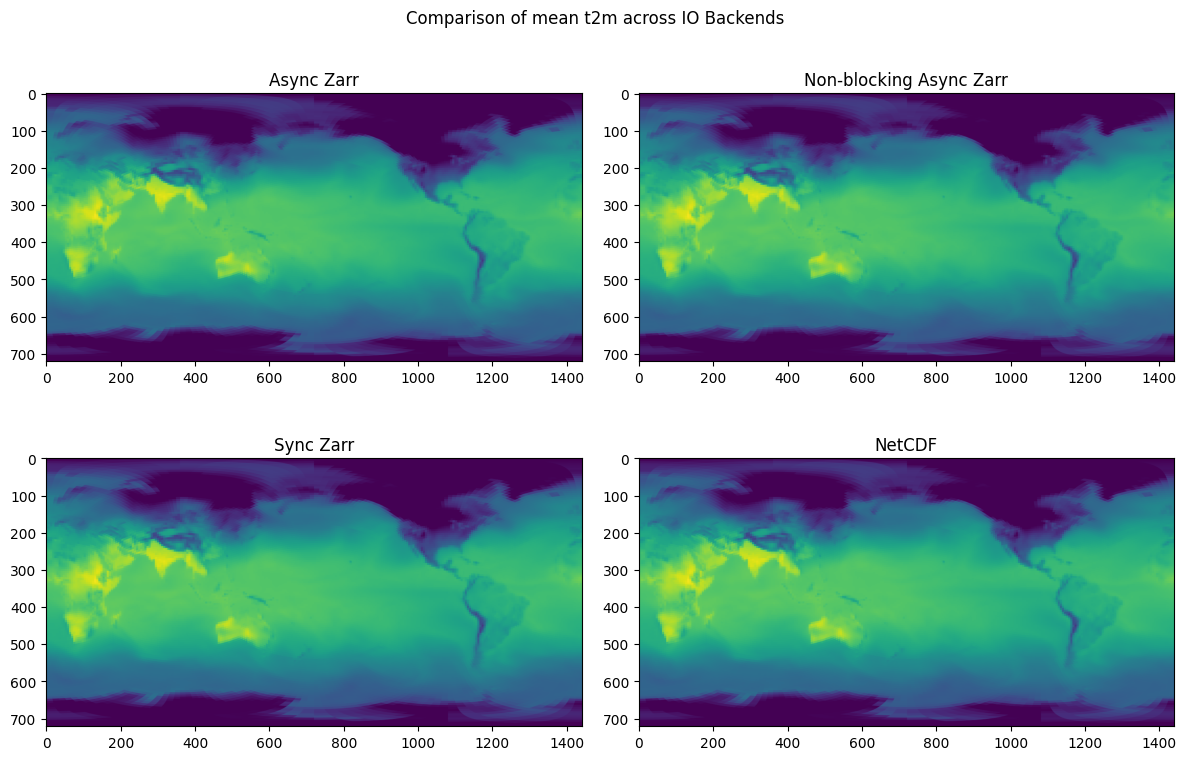

In [17]:
import matplotlib.pyplot as plt
import xarray as xr

# โหลดชุดข้อมูล
ds_async = xr.open_zarr("outputs/17_io_async.zarr", consolidated=False)
ds_nonblocking = xr.open_zarr(
    "outputs/17_io_nonblocking_async.zarr", consolidated=False
)
ds_sync = xr.open_zarr("outputs/17_io_sync.zarr")
ds_nc = xr.open_dataset("outputs/17_io_sync.nc")

# สร้างตารางแผนย่อยขนาด 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Comparison of mean t2m across IO Backends")

# พล็อต t2m จากแต่ละชุดข้อมูล
axes[0, 0].imshow(
    ds_async.t2m.isel(time=0, lead_time=8).mean(dim="ensemble"), vmin=250, vmax=320
)
axes[0, 0].set_title("Async Zarr")

axes[0, 1].imshow(
    ds_nonblocking.t2m.isel(time=0, lead_time=8).mean(dim="ensemble"),
    vmin=250,
    vmax=320,
)
axes[0, 1].set_title("Non-blocking Async Zarr")

axes[1, 0].imshow(
    ds_sync.t2m.isel(time=0, lead_time=8).mean(dim="ensemble"), vmin=250, vmax=320
)
axes[1, 0].set_title("Sync Zarr")

axes[1, 1].imshow(
    ds_nc.t2m.isel(time=0, lead_time=8).mean(dim="ensemble"), vmin=250, vmax=320
)
axes[1, 1].set_title("NetCDF")

plt.tight_layout()
plt.savefig("outputs/17_io_performance.jpg", bbox_inches="tight")